# Group Experiment Ratemap Analysis

Aggregates the ratemap analysis across a group of experiments (20 per condition) and
compares the experimental and control groups. For each experiment it loads the cached
301 checkpoint ratemap stack, optionally normalizes it, and walks the timeline computing
per checkpoint metrics: active unit count, mean unit coverage, summed activity and active
unit counts at four representative maze locations, and map to map correlation across
consecutive checkpoints. Each experiment contributes one history per metric.

The histories are stacked across experiments and reduced to a mean and standard deviation
with compute_mean_std, then plotted as group curves with error bands (plot_group_*) and as
per experiment overlays (plot_*_by_experiment). The notebook runs this twice, once for the
experimental group and once for the control group, and ends with direct experimental versus
control comparisons (plot_compare_*).

Set `control` and the group size at the top. Reads caches via update_experiment_ratemaps and
writes figures to Plots/Experimental_group or Plots/Control_group.

### Import libraries

In [2]:
%matplotlib inline
import os
import sys
import csv
import pathlib
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

### Import Autoencoder class

In [4]:
folder_path = str(pathlib.Path().resolve().parents[1])
data_path = 'D:\RORcogmaps_data'
print("Folder path =", folder_path)
sys.path.append(folder_path + '/Notebooks/Spatial_AE/')

from analysis import *
from plotting import *
from data import *

Folder path = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps


### Check GPU

In [6]:
print("CUDA is available =", torch.cuda.is_available())
print("CUDA device count =", torch.cuda.device_count())
if torch.cuda.device_count() > 1:
    os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
print("CUDA device name =", torch.cuda.get_device_name(0))

CUDA is available = True
CUDA device count = 2
CUDA device name = NVIDIA RTX A5000


### Hyperparameters

In [8]:
control = False
save_plots = True
normalize = True #Normalize ratemaps

#Model
n_hidden = 200
batch_size = 256
num_epochs = 100
learning_rate = 1e-4
C_factor = 1e3
alpha = 1e5

#Others
total_experiments = 20
experiment_n = 1 #Start = 1
trial_t = 0

actv_threshold = 0.05

if control == False:
    envs = ['Tmaze_0', 'Tmaze_1', 'Tmaze_2']
else:
    envs = ['Tmaze_v0a', 'Tmaze_v0b', 'Tmaze_v0c']

In [9]:
if control == False:
    plot_folder_path = folder_path + '/Plots/Experimental_group'
else:
    plot_folder_path = folder_path + '/Plots/Control_group'

os.makedirs(plot_folder_path, exist_ok=True)

### Import ratemaps

In [11]:
arr, CACHE_DIR = update_experiment_ratemaps(experiment_n, data_path, control=control)
if normalize == True:
    print('Normalizing ratemaps')
    arr = normalize_ratemaps(arr)

CACHE_DIR = D:\RORcogmaps_data/Models/Experimental/Exp1_cache_ratemaps
Normalizing ratemaps


### Explore a single experiment

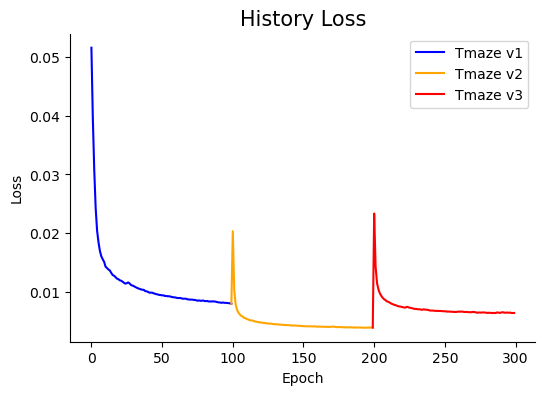

In [13]:
history_loss = load_loss_history(CACHE_DIR)
plot_history_loss(history_loss)

In [14]:
trial_idx = 300
trial_ratemaps = arr[trial_idx]
trial_ratemaps.shape

(200, 50, 50)

In [15]:
plot_ratemaps(trial_ratemaps[:100], path=plot_folder_path, save=save_plots)

In [16]:
def compute_mean_std(data):
    arr = np.array(data)        # shape (15, 301)
    mean = arr.mean(axis=0)     # shape (301,)
    std  = arr.std(axis=0)      # shape (301,)
    return mean, std

In [17]:
def format_dataset(env):
    data_path = folder_path + '/Datasets/' + env
    csv_filename = data_path + "/data.csv"

    img_filename_list = os.listdir(data_path)
    num_images = len(img_filename_list) -1 

    return data_path, csv_filename, num_images

#####################################################################

def Load_env_dataset(env_idx):
    # Load dataset every T-maze version
    env = envs[env_idx] #Choose environment index
    data_path, csv_filename, num_images = format_dataset(env)

    print("Dataset Path =", data_path)
    print("Num. Images in Dataset =", num_images)
    
    dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)

    return dataset, csv_filename

## Data processing loop

# Experimental group

In [20]:
RO_all_history_loss = []
RO_all_num_active_units = []
RO_all_mean_unit_coverage_history = []
RO_all_correlation_history = []

RO_all_TL_rep_unit_sum_history = []
RO_all_TC_rep_unit_sum_history = []
RO_all_TR_rep_unit_sum_history = []
RO_all_BC_rep_unit_sum_history = []

RO_all_TL_rep_unit_count_history = []
RO_all_TC_rep_unit_count_history = []
RO_all_TR_rep_unit_count_history = []
RO_all_BC_rep_unit_count_history = []


for i in range(total_experiments):
    
    arr, CACHE_DIR = update_experiment_ratemaps(experiment_n + i, data_path, control=control)
    history_loss = load_loss_history(CACHE_DIR)

    if normalize == True:
        print('Normalizing ratemaps for experiment', str(experiment_n + i))
        arr = normalize_ratemaps(arr)
    else:
        print('Importing ratemaps from experiment', str(experiment_n + i))

    num_active_units = []
    mean_unit_coverage_history = []
    correlation_history = []
    
    TL_rep_unit_sum_history = []
    TC_rep_unit_sum_history = []
    TR_rep_unit_sum_history = []
    BC_rep_unit_sum_history = []
    
    TL_rep_unit_count_history = []
    TC_rep_unit_count_history = []
    TR_rep_unit_count_history = []
    BC_rep_unit_count_history = []

    for t in range(arr.shape[0]):
        if t == 0:
            max_coverage = get_max_coverage(arr[t], actv_threshold)
        
        num_active_units.append(get_num_active_units(arr[t], actv_threshold))
        mean_unit_coverage_history.append(get_mean_unit_coverage_at_t(arr[t], max_coverage, actv_threshold))
    
        # Unit activity at representative locations
        TL_sum, TC_sum, TR_sum, BC_sum = representative_unit_sums(arr[t])
        TL_rep_unit_sum_history.append(TL_sum)
        TC_rep_unit_sum_history.append(TC_sum)
        TR_rep_unit_sum_history.append(TR_sum)
        BC_rep_unit_sum_history.append(BC_sum)
        
        TL_count, TC_count, TR_count, BC_count = representative_unit_count(arr[t], actv_threshold)
        TL_rep_unit_count_history.append(TL_count)
        TC_rep_unit_count_history.append(TC_count)
        TR_rep_unit_count_history.append(TR_count)
        BC_rep_unit_count_history.append(BC_count)
    
        # Measure map correlation
        if t != 0:
            flat_t0 = prev_ratemaps.flatten()
            flat_t1 = arr[t].flatten()
            corr = np.corrcoef(flat_t0, flat_t1)[0, 1]
            correlation_history.append(corr)
    
        prev_ratemaps = arr[t]

    RO_all_history_loss.append(history_loss)
    RO_all_num_active_units.append(num_active_units)
    RO_all_mean_unit_coverage_history.append(mean_unit_coverage_history)
    RO_all_correlation_history.append(correlation_history)
    RO_all_TL_rep_unit_sum_history.append(TL_rep_unit_sum_history)
    RO_all_TC_rep_unit_sum_history.append(TC_rep_unit_sum_history)
    RO_all_TR_rep_unit_sum_history.append(TR_rep_unit_sum_history)
    RO_all_BC_rep_unit_sum_history.append(BC_rep_unit_sum_history)
    RO_all_TL_rep_unit_count_history.append(TL_rep_unit_count_history)
    RO_all_TC_rep_unit_count_history.append(TC_rep_unit_count_history)
    RO_all_TR_rep_unit_count_history.append(TR_rep_unit_count_history)
    RO_all_BC_rep_unit_count_history.append(BC_rep_unit_count_history)

CACHE_DIR = D:\RORcogmaps_data/Models/Experimental/Exp1_cache_ratemaps
Normalizing ratemaps for experiment 1
Max. coverage = 1584
CACHE_DIR = D:\RORcogmaps_data/Models/Experimental/Exp2_cache_ratemaps
Normalizing ratemaps for experiment 2
Max. coverage = 1583
CACHE_DIR = D:\RORcogmaps_data/Models/Experimental/Exp3_cache_ratemaps
Normalizing ratemaps for experiment 3
Max. coverage = 1584
CACHE_DIR = D:\RORcogmaps_data/Models/Experimental/Exp4_cache_ratemaps
Normalizing ratemaps for experiment 4
Max. coverage = 1590
CACHE_DIR = D:\RORcogmaps_data/Models/Experimental/Exp5_cache_ratemaps
Normalizing ratemaps for experiment 5
Max. coverage = 1582


In [21]:
RO_all_mean_unit_coverage = []
for i in range(total_experiments):
    RO_all_mean_unit_coverage.append([x * 100 for x in RO_all_mean_unit_coverage_history[i]])

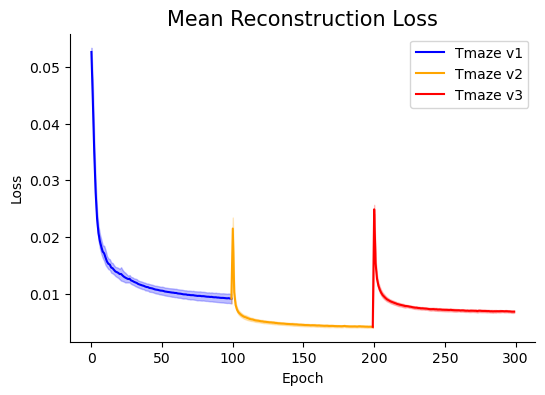

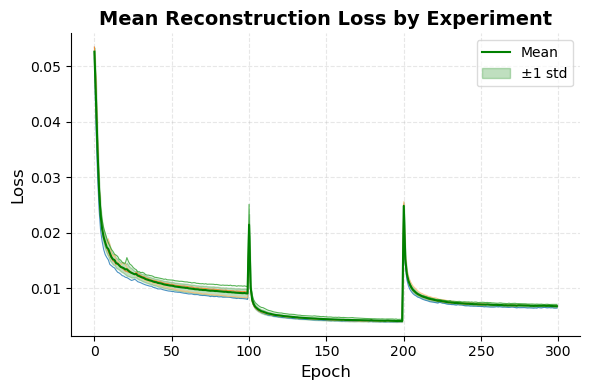

In [22]:
RO_loss_mean, RO_loss_std = compute_mean_std(RO_all_history_loss)
plot_group_history_loss(RO_loss_mean, RO_loss_std, save=save_plots, path=plot_folder_path)
plot_loss_history_by_experiment(RO_all_history_loss, save=save_plots, path=plot_folder_path)

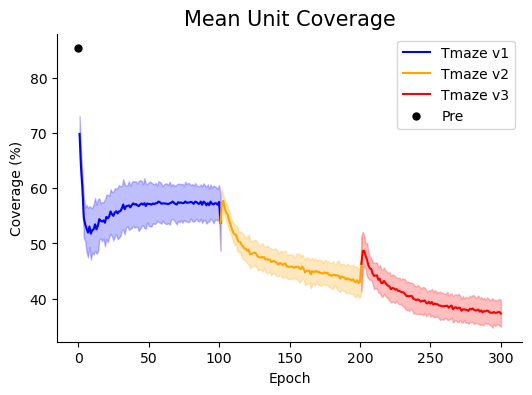

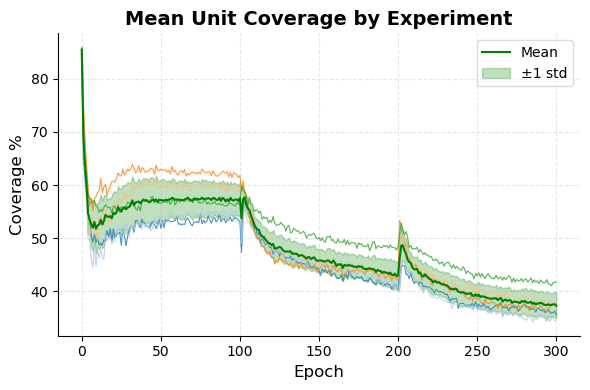

In [24]:
RO_coverage_mean, RO_coverage_std = compute_mean_std(RO_all_mean_unit_coverage)
plot_group_unit_coverage(RO_coverage_mean, RO_coverage_std, save=save_plots, path=plot_folder_path)
plot_unit_coverage_by_experiment(RO_all_mean_unit_coverage, save=save_plots, path=plot_folder_path)

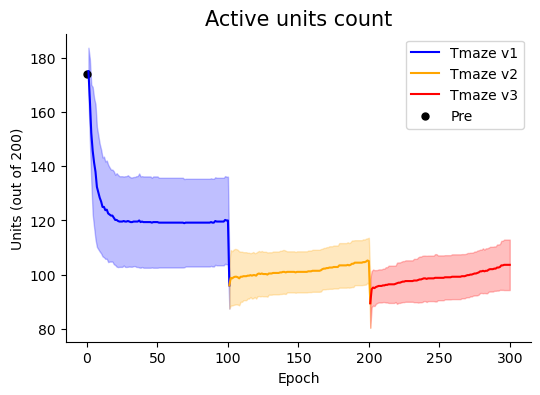

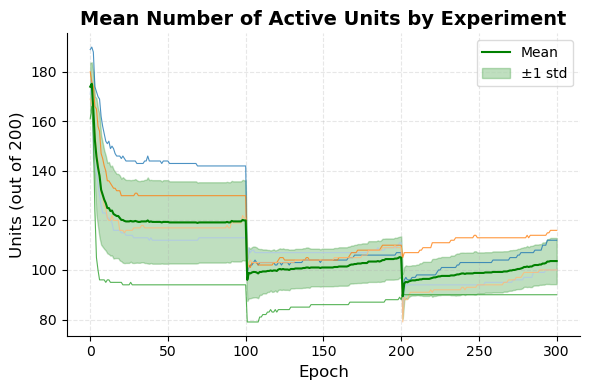

In [25]:
RO_active_units_mean, RO_active_units_std = compute_mean_std(RO_all_num_active_units)
plot_group_active_units_count(RO_active_units_mean, RO_active_units_std, save=save_plots, path=plot_folder_path)
plot_active_units_count_by_experiment(RO_all_num_active_units, save=save_plots, path=plot_folder_path)

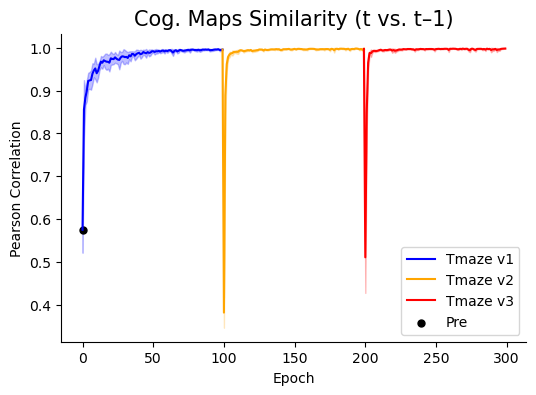

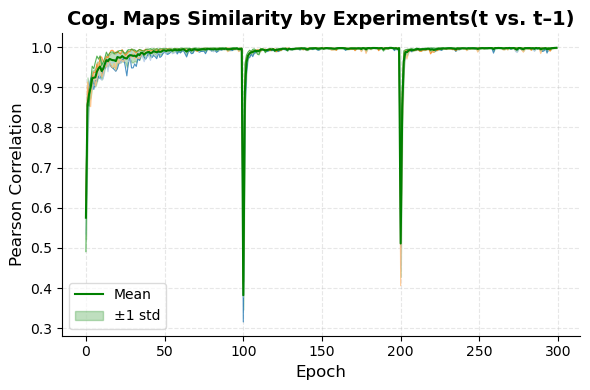

In [26]:
RO_map_correlation_mean, RO_map_correlation_std = compute_mean_std(RO_all_correlation_history)
plot_group_cogmap_correlation(RO_map_correlation_mean, RO_map_correlation_std, save=save_plots, path=plot_folder_path)
plot_cogmap_correlation_by_experiment(RO_all_correlation_history, save=save_plots, path=plot_folder_path)

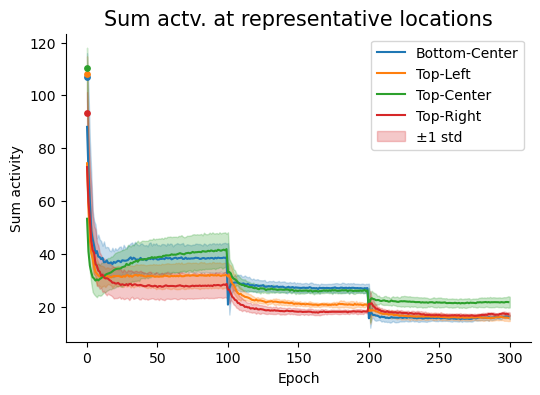

In [27]:
plot_group_activity_rep_loc(RO_all_BC_rep_unit_sum_history, RO_all_TL_rep_unit_sum_history, RO_all_TC_rep_unit_sum_history, RO_all_TR_rep_unit_sum_history,  save=save_plots, path=plot_folder_path)

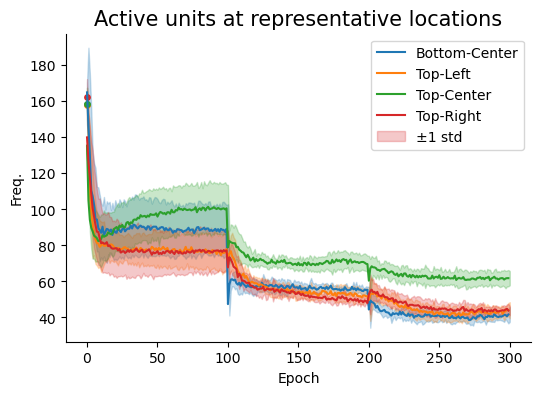

In [28]:
plot_group_units_rep_loc(RO_all_BC_rep_unit_count_history, RO_all_TL_rep_unit_count_history, RO_all_TC_rep_unit_count_history, RO_all_TR_rep_unit_count_history, save=save_plots, path=plot_folder_path)

# Control group

In [30]:
control = True
total_experiments = 20
envs = ['Tmaze_v0a', 'Tmaze_v0b', 'Tmaze_v0c']

In [31]:
control_all_history_loss = []
control_all_num_active_units = []
control_all_mean_unit_coverage_history = []
control_all_correlation_history = []

control_all_TL_rep_unit_sum_history = []
control_all_TC_rep_unit_sum_history = []
control_all_TR_rep_unit_sum_history = []
control_all_BC_rep_unit_sum_history = []

control_all_TL_rep_unit_count_history = []
control_all_TC_rep_unit_count_history = []
control_all_TR_rep_unit_count_history = []
control_all_BC_rep_unit_count_history = []


for i in range(total_experiments):
    
    arr, CACHE_DIR = update_experiment_ratemaps(experiment_n + i, data_path, control=control)
    history_loss = load_loss_history(CACHE_DIR)

    if normalize == True:
        print('Normalizing ratemaps for experiment', str(experiment_n + i))
        arr = normalize_ratemaps(arr)
    else:
        print('Importing ratemaps from experiment', str(experiment_n + i))

    num_active_units = []
    mean_unit_coverage_history = []
    correlation_history = []
    
    TL_rep_unit_sum_history = []
    TC_rep_unit_sum_history = []
    TR_rep_unit_sum_history = []
    BC_rep_unit_sum_history = []
    
    TL_rep_unit_count_history = []
    TC_rep_unit_count_history = []
    TR_rep_unit_count_history = []
    BC_rep_unit_count_history = []

    for t in range(arr.shape[0]):
        if t == 0:
            max_coverage = get_max_coverage(arr[t], actv_threshold)
        
        num_active_units.append(get_num_active_units(arr[t], actv_threshold))
        mean_unit_coverage_history.append(get_mean_unit_coverage_at_t(arr[t], max_coverage, actv_threshold))
    
        # Unit activity at representative locations
        TL_sum, TC_sum, TR_sum, BC_sum = representative_unit_sums(arr[t])
        TL_rep_unit_sum_history.append(TL_sum)
        TC_rep_unit_sum_history.append(TC_sum)
        TR_rep_unit_sum_history.append(TR_sum)
        BC_rep_unit_sum_history.append(BC_sum)
        
        TL_count, TC_count, TR_count, BC_count = representative_unit_count(arr[t], actv_threshold)
        TL_rep_unit_count_history.append(TL_count)
        TC_rep_unit_count_history.append(TC_count)
        TR_rep_unit_count_history.append(TR_count)
        BC_rep_unit_count_history.append(BC_count)
    
        # Measure map correlation
        if t != 0:
            flat_t0 = prev_ratemaps.flatten()
            flat_t1 = arr[t].flatten()
            corr = np.corrcoef(flat_t0, flat_t1)[0, 1]
            correlation_history.append(corr)
    
        prev_ratemaps = arr[t]

    control_all_history_loss.append(history_loss)
    control_all_num_active_units.append(num_active_units)
    control_all_mean_unit_coverage_history.append(mean_unit_coverage_history)
    control_all_correlation_history.append(correlation_history)
    control_all_TL_rep_unit_sum_history.append(TL_rep_unit_sum_history)
    control_all_TC_rep_unit_sum_history.append(TC_rep_unit_sum_history)
    control_all_TR_rep_unit_sum_history.append(TR_rep_unit_sum_history)
    control_all_BC_rep_unit_sum_history.append(BC_rep_unit_sum_history)
    control_all_TL_rep_unit_count_history.append(TL_rep_unit_count_history)
    control_all_TC_rep_unit_count_history.append(TC_rep_unit_count_history)
    control_all_TR_rep_unit_count_history.append(TR_rep_unit_count_history)
    control_all_BC_rep_unit_count_history.append(BC_rep_unit_count_history)

CACHE_DIR = D:\RORcogmaps_data/Models/Control/Control-Exp1_cache_ratemaps
Normalizing ratemaps for experiment 1
Max. coverage = 1656
CACHE_DIR = D:\RORcogmaps_data/Models/Control/Control-Exp2_cache_ratemaps
Normalizing ratemaps for experiment 2
Max. coverage = 1658
CACHE_DIR = D:\RORcogmaps_data/Models/Control/Control-Exp3_cache_ratemaps
Normalizing ratemaps for experiment 3
Max. coverage = 1645
CACHE_DIR = D:\RORcogmaps_data/Models/Control/Control-Exp4_cache_ratemaps
Normalizing ratemaps for experiment 4
Max. coverage = 1648
CACHE_DIR = D:\RORcogmaps_data/Models/Control/Control-Exp5_cache_ratemaps
Normalizing ratemaps for experiment 5
Max. coverage = 1661


In [32]:
control_all_mean_unit_coverage = []
for i in range(total_experiments):
    control_all_mean_unit_coverage.append([x * 100 for x in control_all_mean_unit_coverage_history[i]])

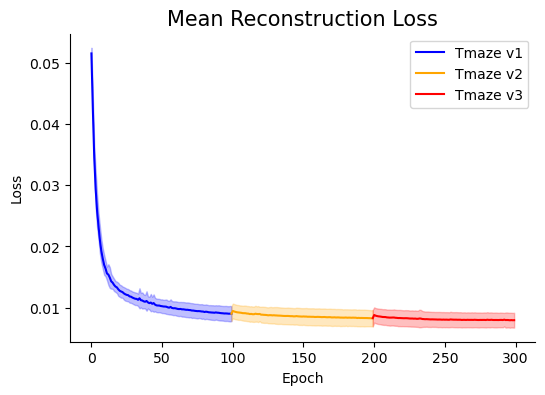

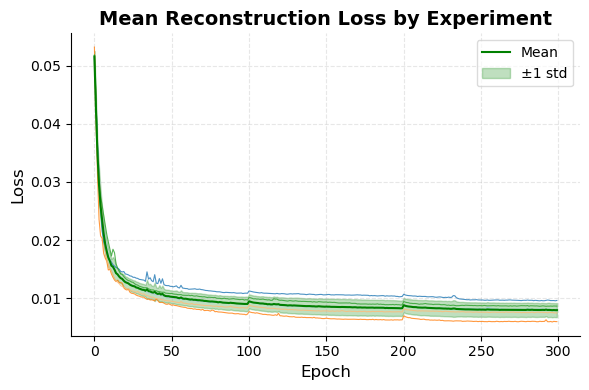

In [33]:
control_loss_mean, control_loss_std = compute_mean_std(control_all_history_loss)
plot_group_history_loss(control_loss_mean, control_loss_std, save=save_plots, path=plot_folder_path)
plot_loss_history_by_experiment(control_all_history_loss, save=save_plots, path=plot_folder_path)

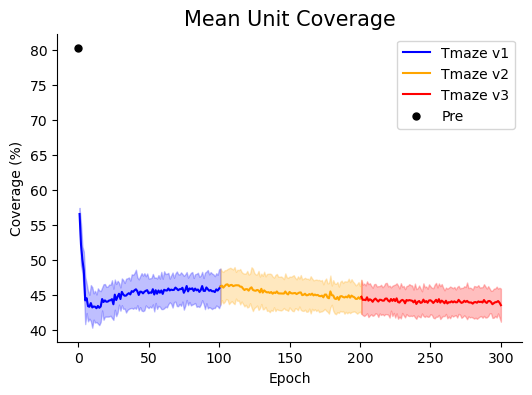

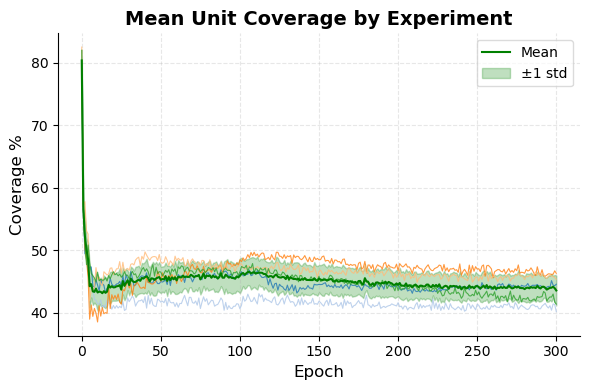

In [34]:
control_coverage_mean, control_coverage_std = compute_mean_std(control_all_mean_unit_coverage)
plot_group_unit_coverage(control_coverage_mean, control_coverage_std, save=save_plots, path=plot_folder_path)
plot_unit_coverage_by_experiment(control_all_mean_unit_coverage, save=save_plots, path=plot_folder_path)

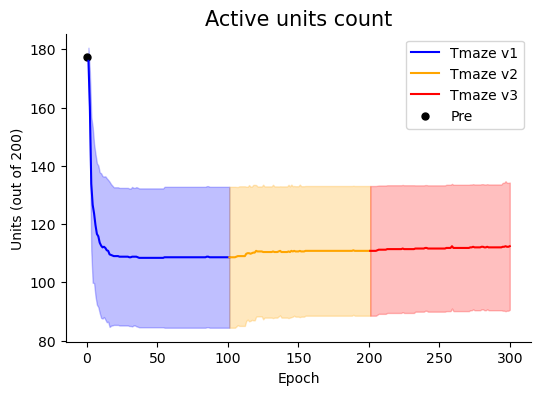

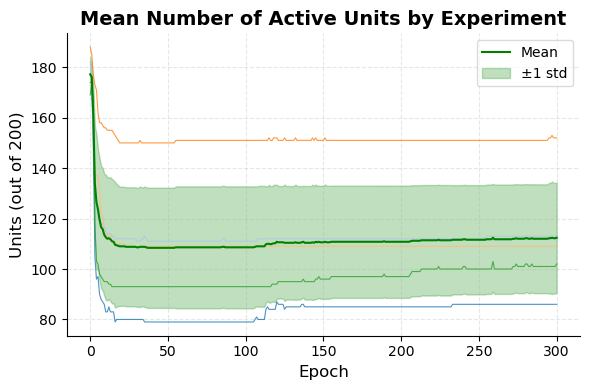

In [35]:
control_active_units_mean, control_active_units_std = compute_mean_std(control_all_num_active_units)
plot_group_active_units_count(control_active_units_mean, control_active_units_std, save=save_plots, path=plot_folder_path)
plot_active_units_count_by_experiment(control_all_num_active_units, save=save_plots, path=plot_folder_path)

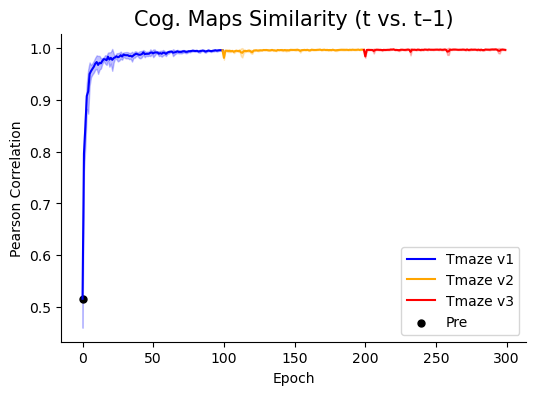

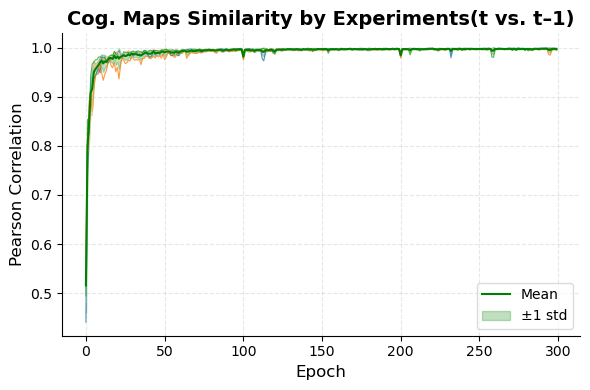

In [36]:
control_map_correlation_mean, control_map_correlation_std = compute_mean_std(control_all_correlation_history)
plot_group_cogmap_correlation(control_map_correlation_mean, control_map_correlation_std, save=save_plots, path=plot_folder_path)
plot_cogmap_correlation_by_experiment(control_all_correlation_history, save=save_plots, path=plot_folder_path)

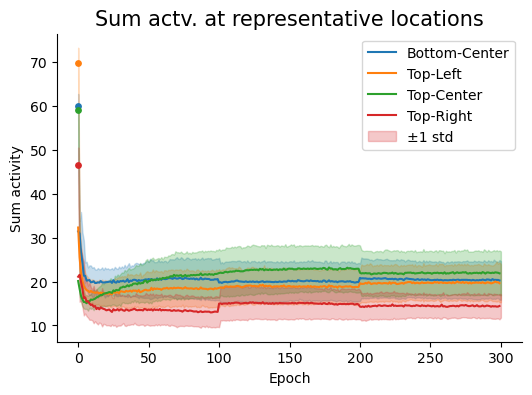

In [37]:
plot_group_activity_rep_loc(control_all_BC_rep_unit_sum_history, control_all_TL_rep_unit_sum_history, control_all_TC_rep_unit_sum_history, control_all_TR_rep_unit_sum_history,  save=save_plots, path=plot_folder_path)

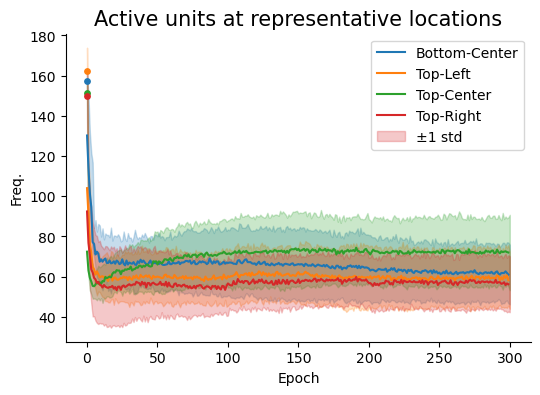

In [38]:
plot_group_units_rep_loc(control_all_BC_rep_unit_count_history, control_all_TL_rep_unit_count_history, control_all_TC_rep_unit_count_history, control_all_TR_rep_unit_count_history, save=save_plots, path=plot_folder_path)

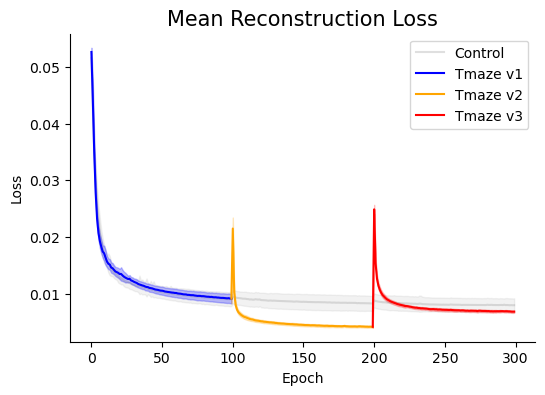

In [39]:
plot_compare_loss_history(RO_loss_mean, control_loss_mean, RO_loss_std, control_loss_std, figsize=(6,4), save=save_plots, path=plot_folder_path)

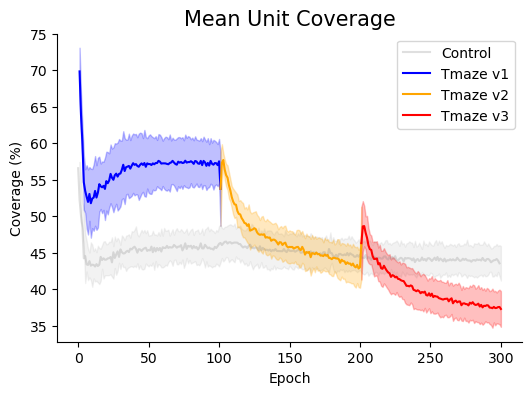

In [40]:
plot_compare_unit_coverage(RO_coverage_mean, control_coverage_mean, RO_coverage_std, control_coverage_std, save=save_plots, path=plot_folder_path)

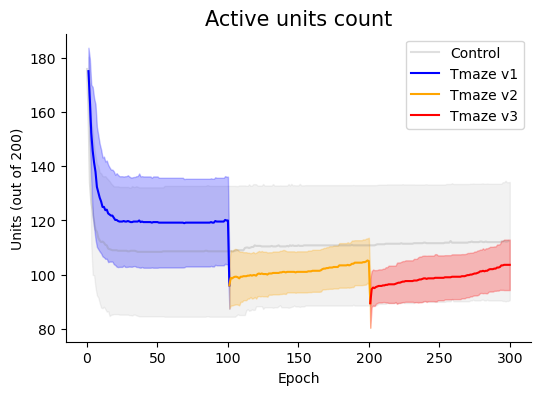

In [41]:
plot_compare_active_units_count(RO_active_units_mean, control_active_units_mean, RO_active_units_std, control_active_units_std, save=save_plots, path=plot_folder_path)

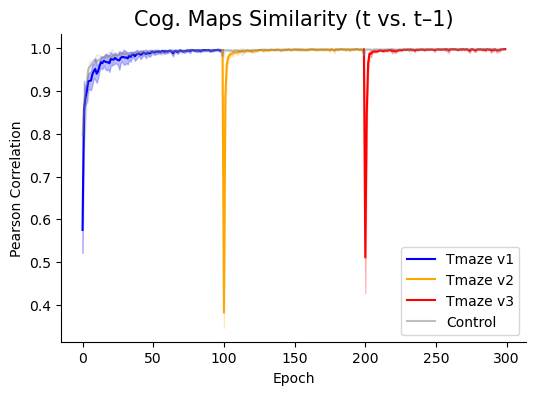

In [42]:
plot_compare_cogmap_correlation(RO_map_correlation_mean, control_map_correlation_mean, RO_map_correlation_std, control_map_correlation_std, save=save_plots, path=plot_folder_path)